# Contexto, Objetivo e Hipóteses

# Carregamento de Dados e Entendimento Inicial dos Dados

* Carregamento das bibliotecas e dados

In [1]:
# ============================================================
# 1. Padrão e Visualização
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")
# Para visualização do SHAP no notebook

# ============================================================
# 2. Estatística e Matemática
# ============================================================
from scipy import stats
from scipy.stats import chi2_contingency

# ============================================================
# 3. Pré-processamento e Transformação
# ============================================================
from sklearn.preprocessing import (
    OneHotEncoder, 
    StandardScaler, 
    LabelEncoder, 
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from tempfile import mkdtemp

# ============================================================
# 4. Modelagem e Seleção
# ============================================================
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# ============================================================
# 5. Algoritmos de Classificação
# ============================================================
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ============================================================
# 6. Métricas de Avaliação
# ============================================================
from sklearn.metrics import (
    f1_score,
    average_precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    brier_score_loss,
    precision_recall_curve
)

from sklearn.calibration import calibration_curve

# ============================================================
# 7. Produção/Exportação
# ============================================================
import joblib

# ============================================================
# 8. Repositório UCI
# ============================================================
from ucimlrepo import fetch_ucirepo

In [2]:
# Dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 

X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 
df = pd.concat([X,y], axis = 1)
df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


* Entendimento inicial

In [3]:
linhas, colunas = df.shape
print(f"Lines: {linhas}, columns: {colunas}")

Lines: 253680, columns: 22


In [4]:
df.dtypes

HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
Diabetes_binary         int64
dtype: object

In [5]:
print("No null values in the dataset")
print('-'*30)
df.isna().sum()

No null values in the dataset
------------------------------


HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

In [6]:
print(f"Duplicated values: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicated values now: {df.duplicated().sum()}")

Duplicated values: 24206
Duplicated values now: 0


In [7]:
# Detectar "missing values" disfarçados
# Valores que representam "não respondeu" ou "não aplicável"
missing_values = [-1, -2]

df = df.replace(missing_values, np.nan)
df.isna().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

* Classificação das variáveis

In [8]:
cols_bin = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack", "PhysActivity",
            "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex"]

cols_ordinal = ["GenHlth", "Education"]

cols_semior = ["Age", "Income"] # ambas são ordinais-não linear. O uso de One-Hot pode superar o encoding padrão.

cols_numeric = ["BMI", "MentHlth", "PhysHlth"]

target = "Diabetes_binary"

* Identificação prévia de possíveis problemas

# Análise Exploratória

* Dataset EDA

In [105]:
df_eda = df.copy()

* Heatamp gênero x diabetes nos ultimos 30 dias (IMC)

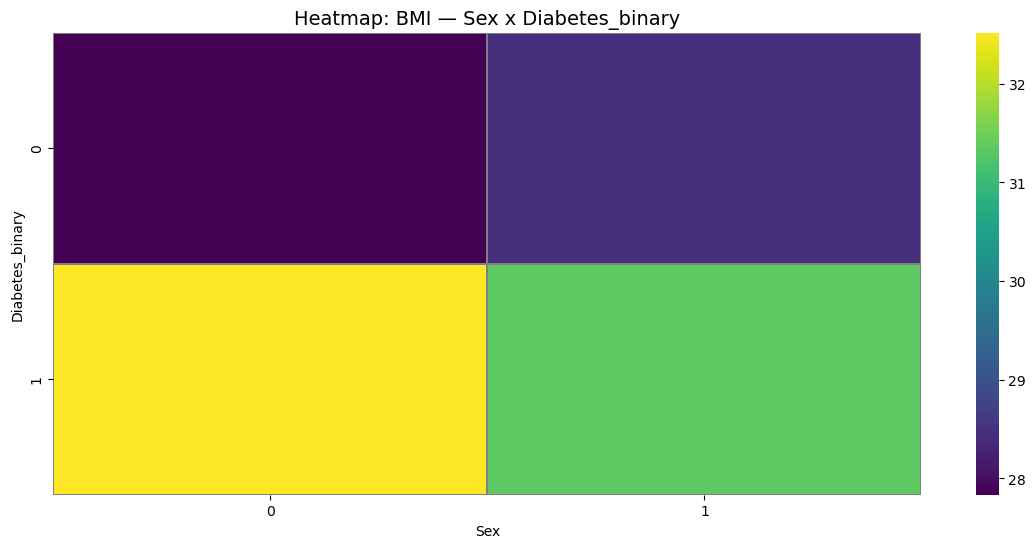

In [10]:
# 0 = female, 1 = male
# physical activity in past 30 days - not including job 0 = no 1 = yes

pivot = df_eda.pivot_table(
    values="BMI",
    index="Diabetes_binary",
    columns="Sex",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot,
    cmap="viridis",
    linewidths=0.1,
    linecolor="gray"
)

plt.title("Heatmap: BMI — Sex x Diabetes_binary", fontsize=14)
plt.xlabel("Sex")
plt.ylabel("Diabetes_binary")
plt.show()

* Heatmap pressão alta x diabetes (IMC) 

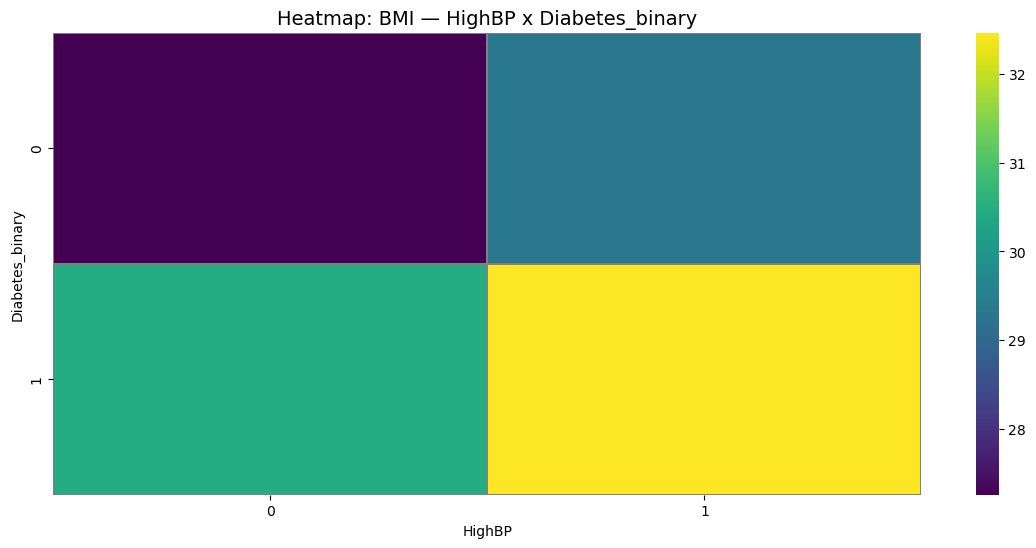

In [11]:
pivot = df_eda.pivot_table(
    values="BMI",
    index="Diabetes_binary",
    columns="HighBP",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot,
    cmap="viridis",
    linewidths=0.1,
    linecolor="gray"
)

plt.title("Heatmap: BMI — HighBP x Diabetes_binary", fontsize=14)
plt.xlabel("HighBP")
plt.ylabel("Diabetes_binary")
plt.show()

* Heatmap colesterol x diabetes (IMC)

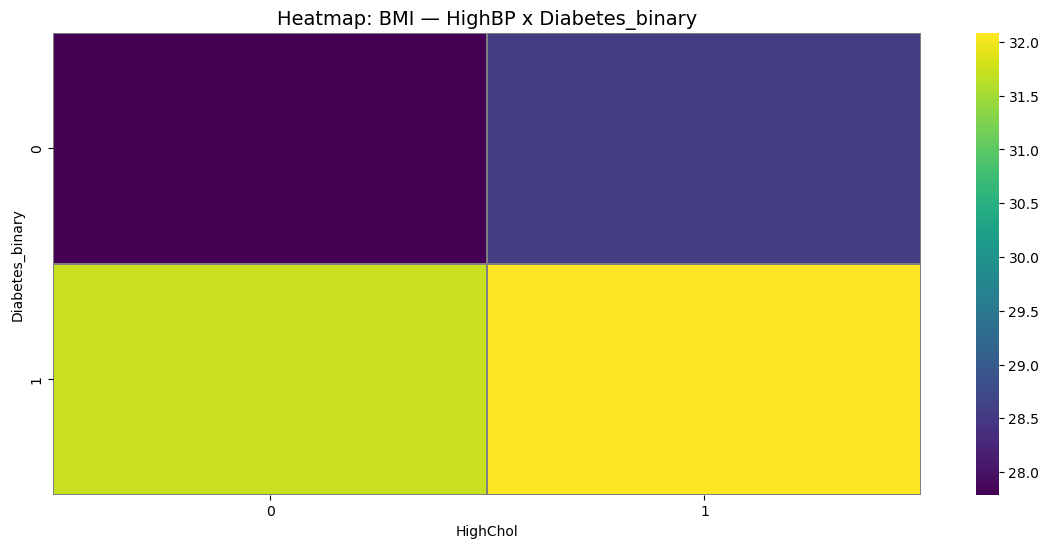

In [12]:
pivot = df_eda.pivot_table(
    values="BMI",
    index="Diabetes_binary",
    columns="HighChol",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot,
    cmap="viridis",
    linewidths=0.1,
    linecolor="gray"
)

plt.title("Heatmap: BMI — HighBP x Diabetes_binary", fontsize=14)
plt.xlabel("HighChol")
plt.ylabel("Diabetes_binary")
plt.show()

* Distribuição da variável target

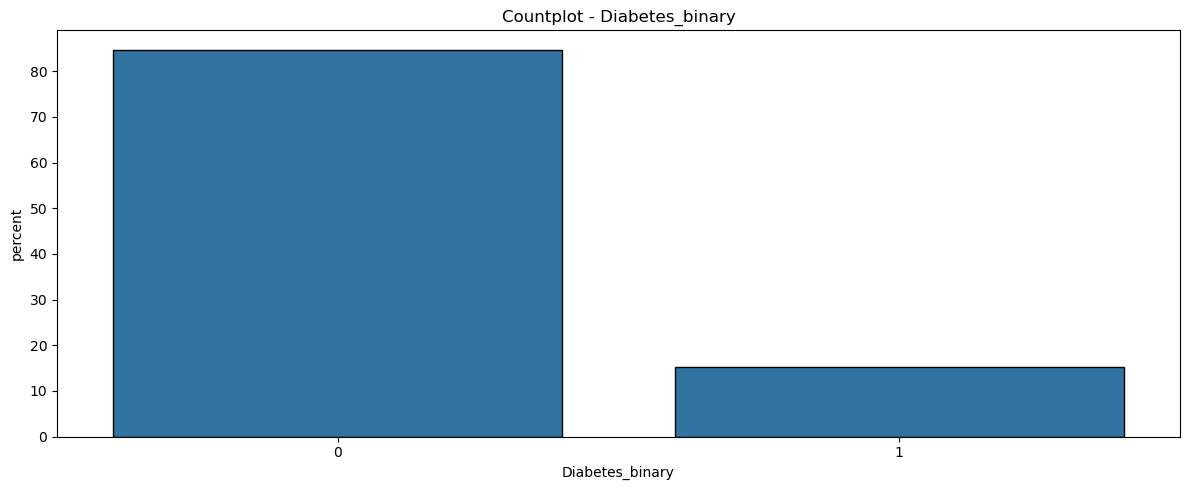

In [13]:
plt.figure(figsize=(12,5))
sns.countplot(data=df_eda, x=target, 
              stat="percent",edgecolor="black")

plt.title(f"Countplot - {target}")

plt.tight_layout()
plt.show()

* Distribuição das variáveis binárias

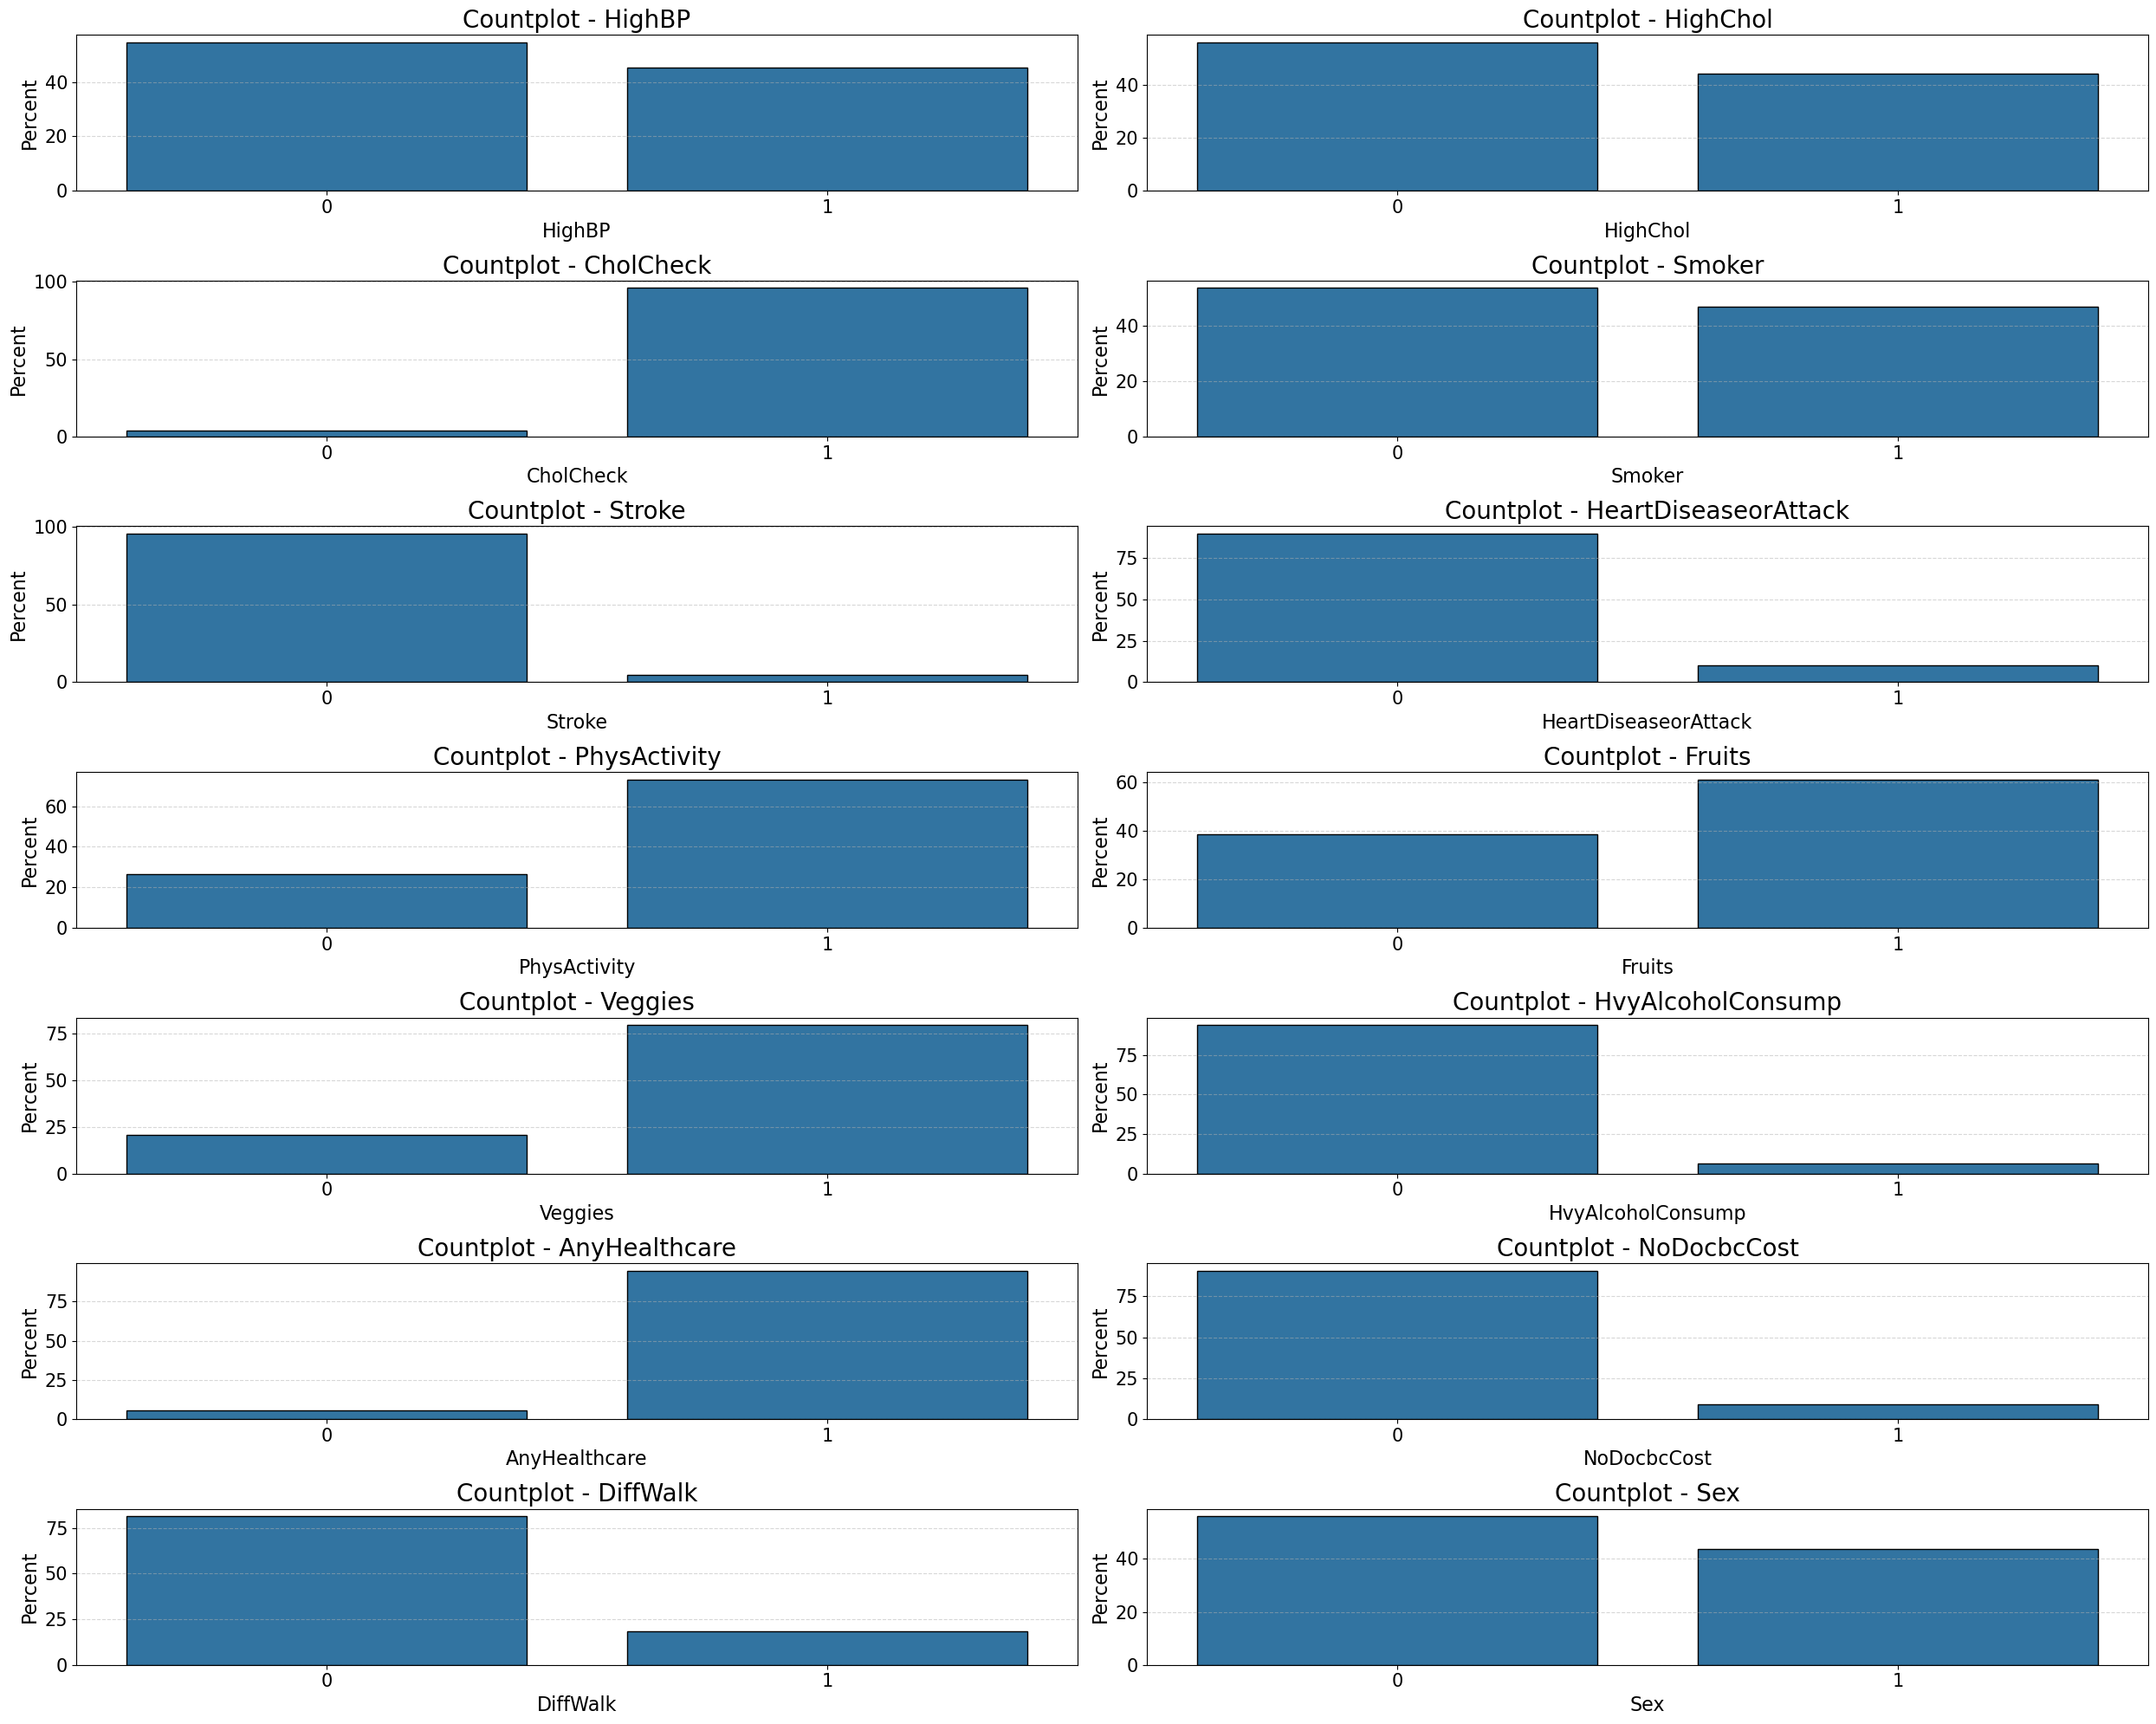

In [14]:
fig, axes = plt.subplots(7, 2, figsize=(25, 20))
axes = axes.flatten()

for ax, col in zip(axes, cols_bin):
    sns.countplot(
        data=df_eda,
        x=col,
        edgecolor="black",
        stat="percent",
        ax=ax
    )
    ax.set_title(f"Countplot - {col}", fontsize=20)
    ax.set_xlabel(col, fontsize=16)
    ax.set_ylabel("Percent",fontsize=16)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params("x", labelsize=15)
    ax.tick_params("y", labelsize=15)

# Caso tenha mais axes do que colunas numéricas
for ax in axes[len(cols_bin):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Distribuição das variáveis ordinais

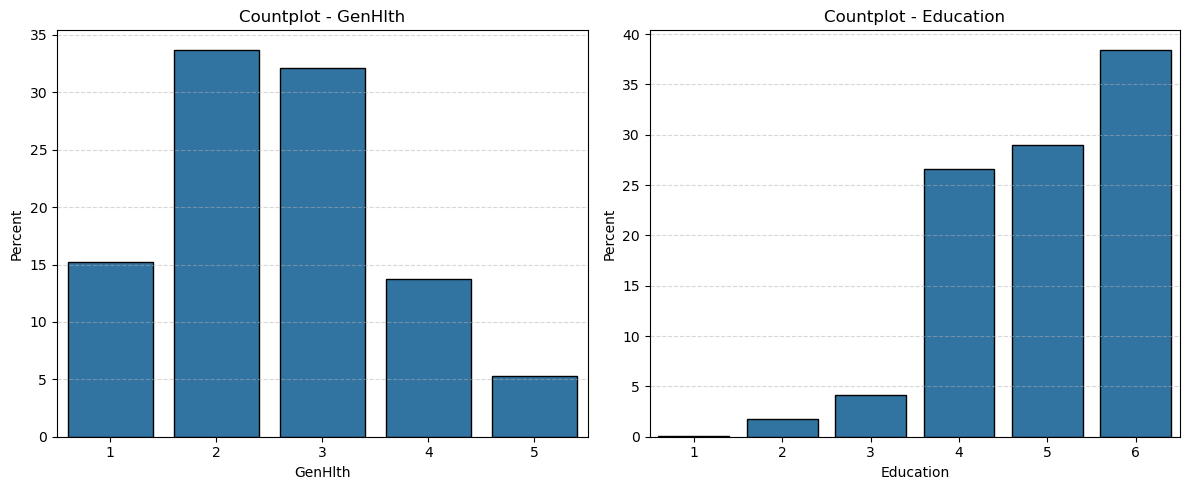

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for ax, col in zip(axes, cols_ordinal):
    sns.countplot(
        data=df_eda,
        x=col,
        edgecolor="black",
        stat="percent",
        ax=ax
    )
    ax.set_title(f"Countplot - {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Percent")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params("x")
    ax.tick_params("y")

# Caso tenha mais axes do que colunas numéricas
for ax in axes[len(cols_ordinal):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Distribuição das variáveis semiordinárias

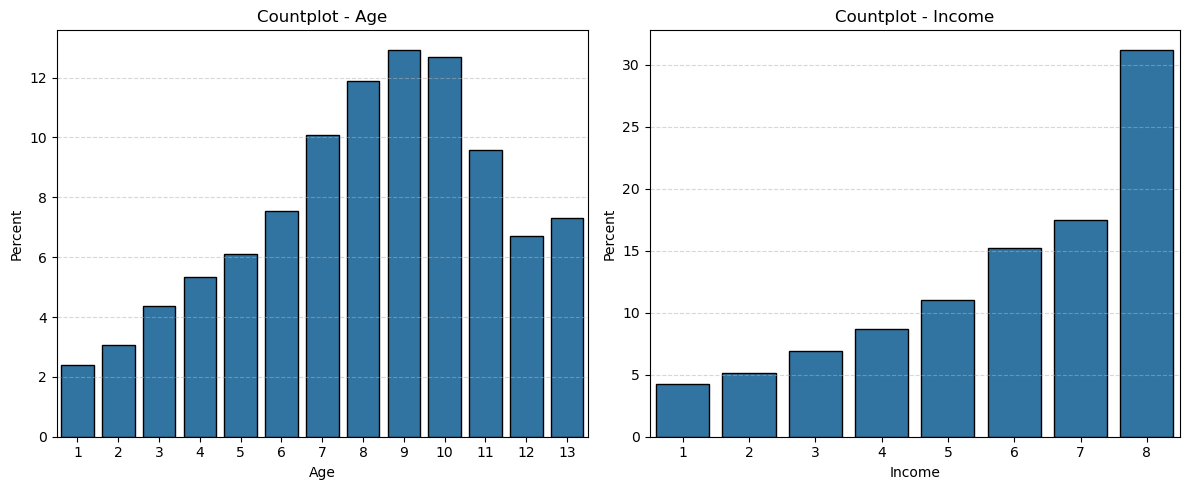

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for ax, col in zip(axes, cols_semior):
    sns.countplot(
        data=df_eda,
        x=col,
        edgecolor="black",
        stat="percent",
        ax=ax
    )
    ax.set_title(f"Countplot - {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Percent")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params("x")
    ax.tick_params("y")

# Caso tenha mais axes do que colunas numéricas
for ax in axes[len(cols_semior):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Distribuição das variáveis numéricas

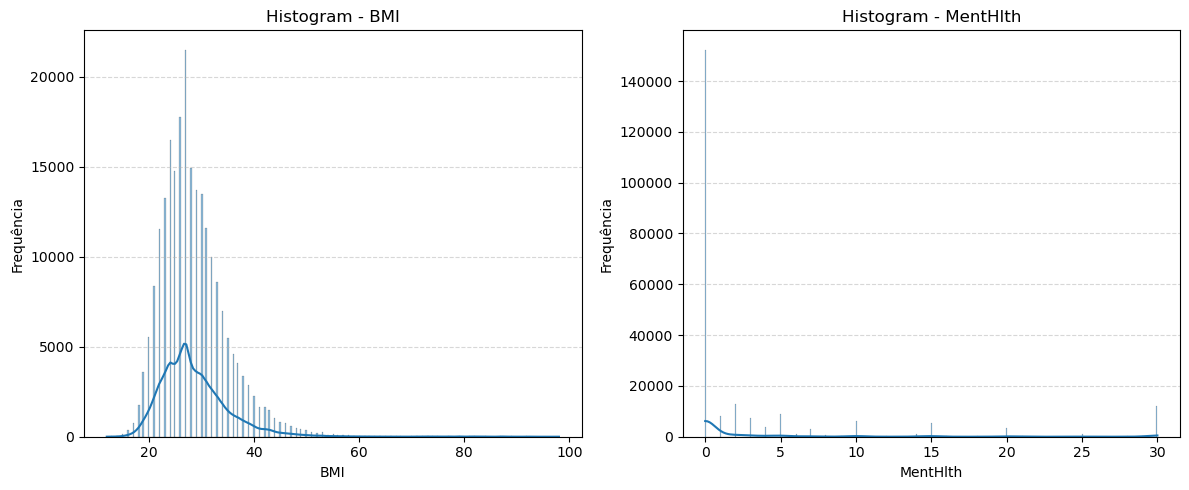

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for ax, col in zip(axes, cols_numeric):
    sns.histplot(
        data=df_eda,
        x=col,
        kde=True,
        edgecolor="black",
        ax=ax
    )
    ax.set_title(f"Histogram - {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequência")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Caso tenha mais axes do que colunas numéricas
for ax in axes[len(cols_numeric):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

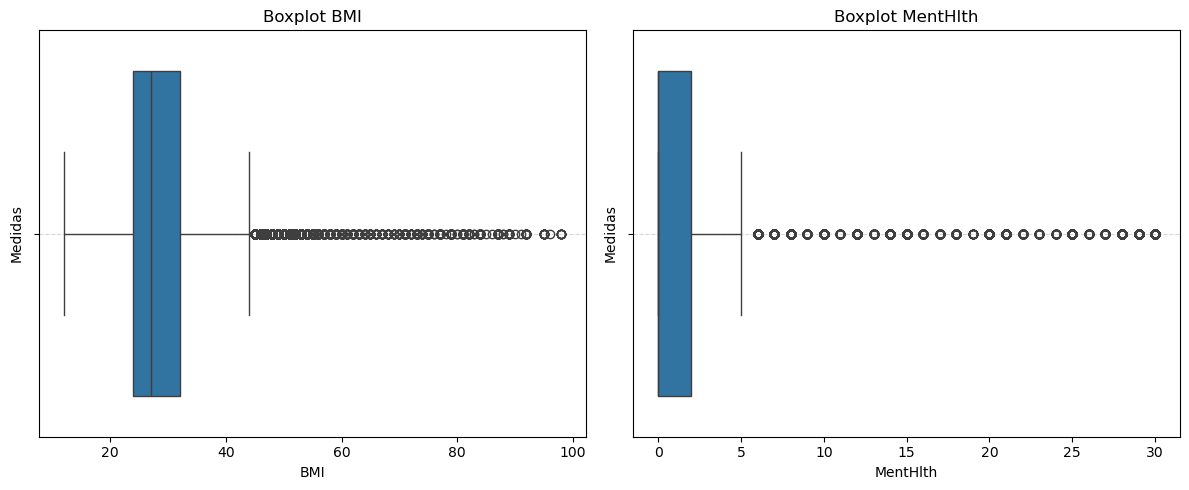

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for ax, col in zip(axes, cols_numeric):
    sns.boxplot(
        data=df_eda,
        x=col,
        ax=ax
    )
    ax.set_title(f"Boxplot {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Medidas")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Caso tenha mais axes do que colunas numéricas
for ax in axes[len(cols_numeric):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Relação da variável target com as variáveis binárias

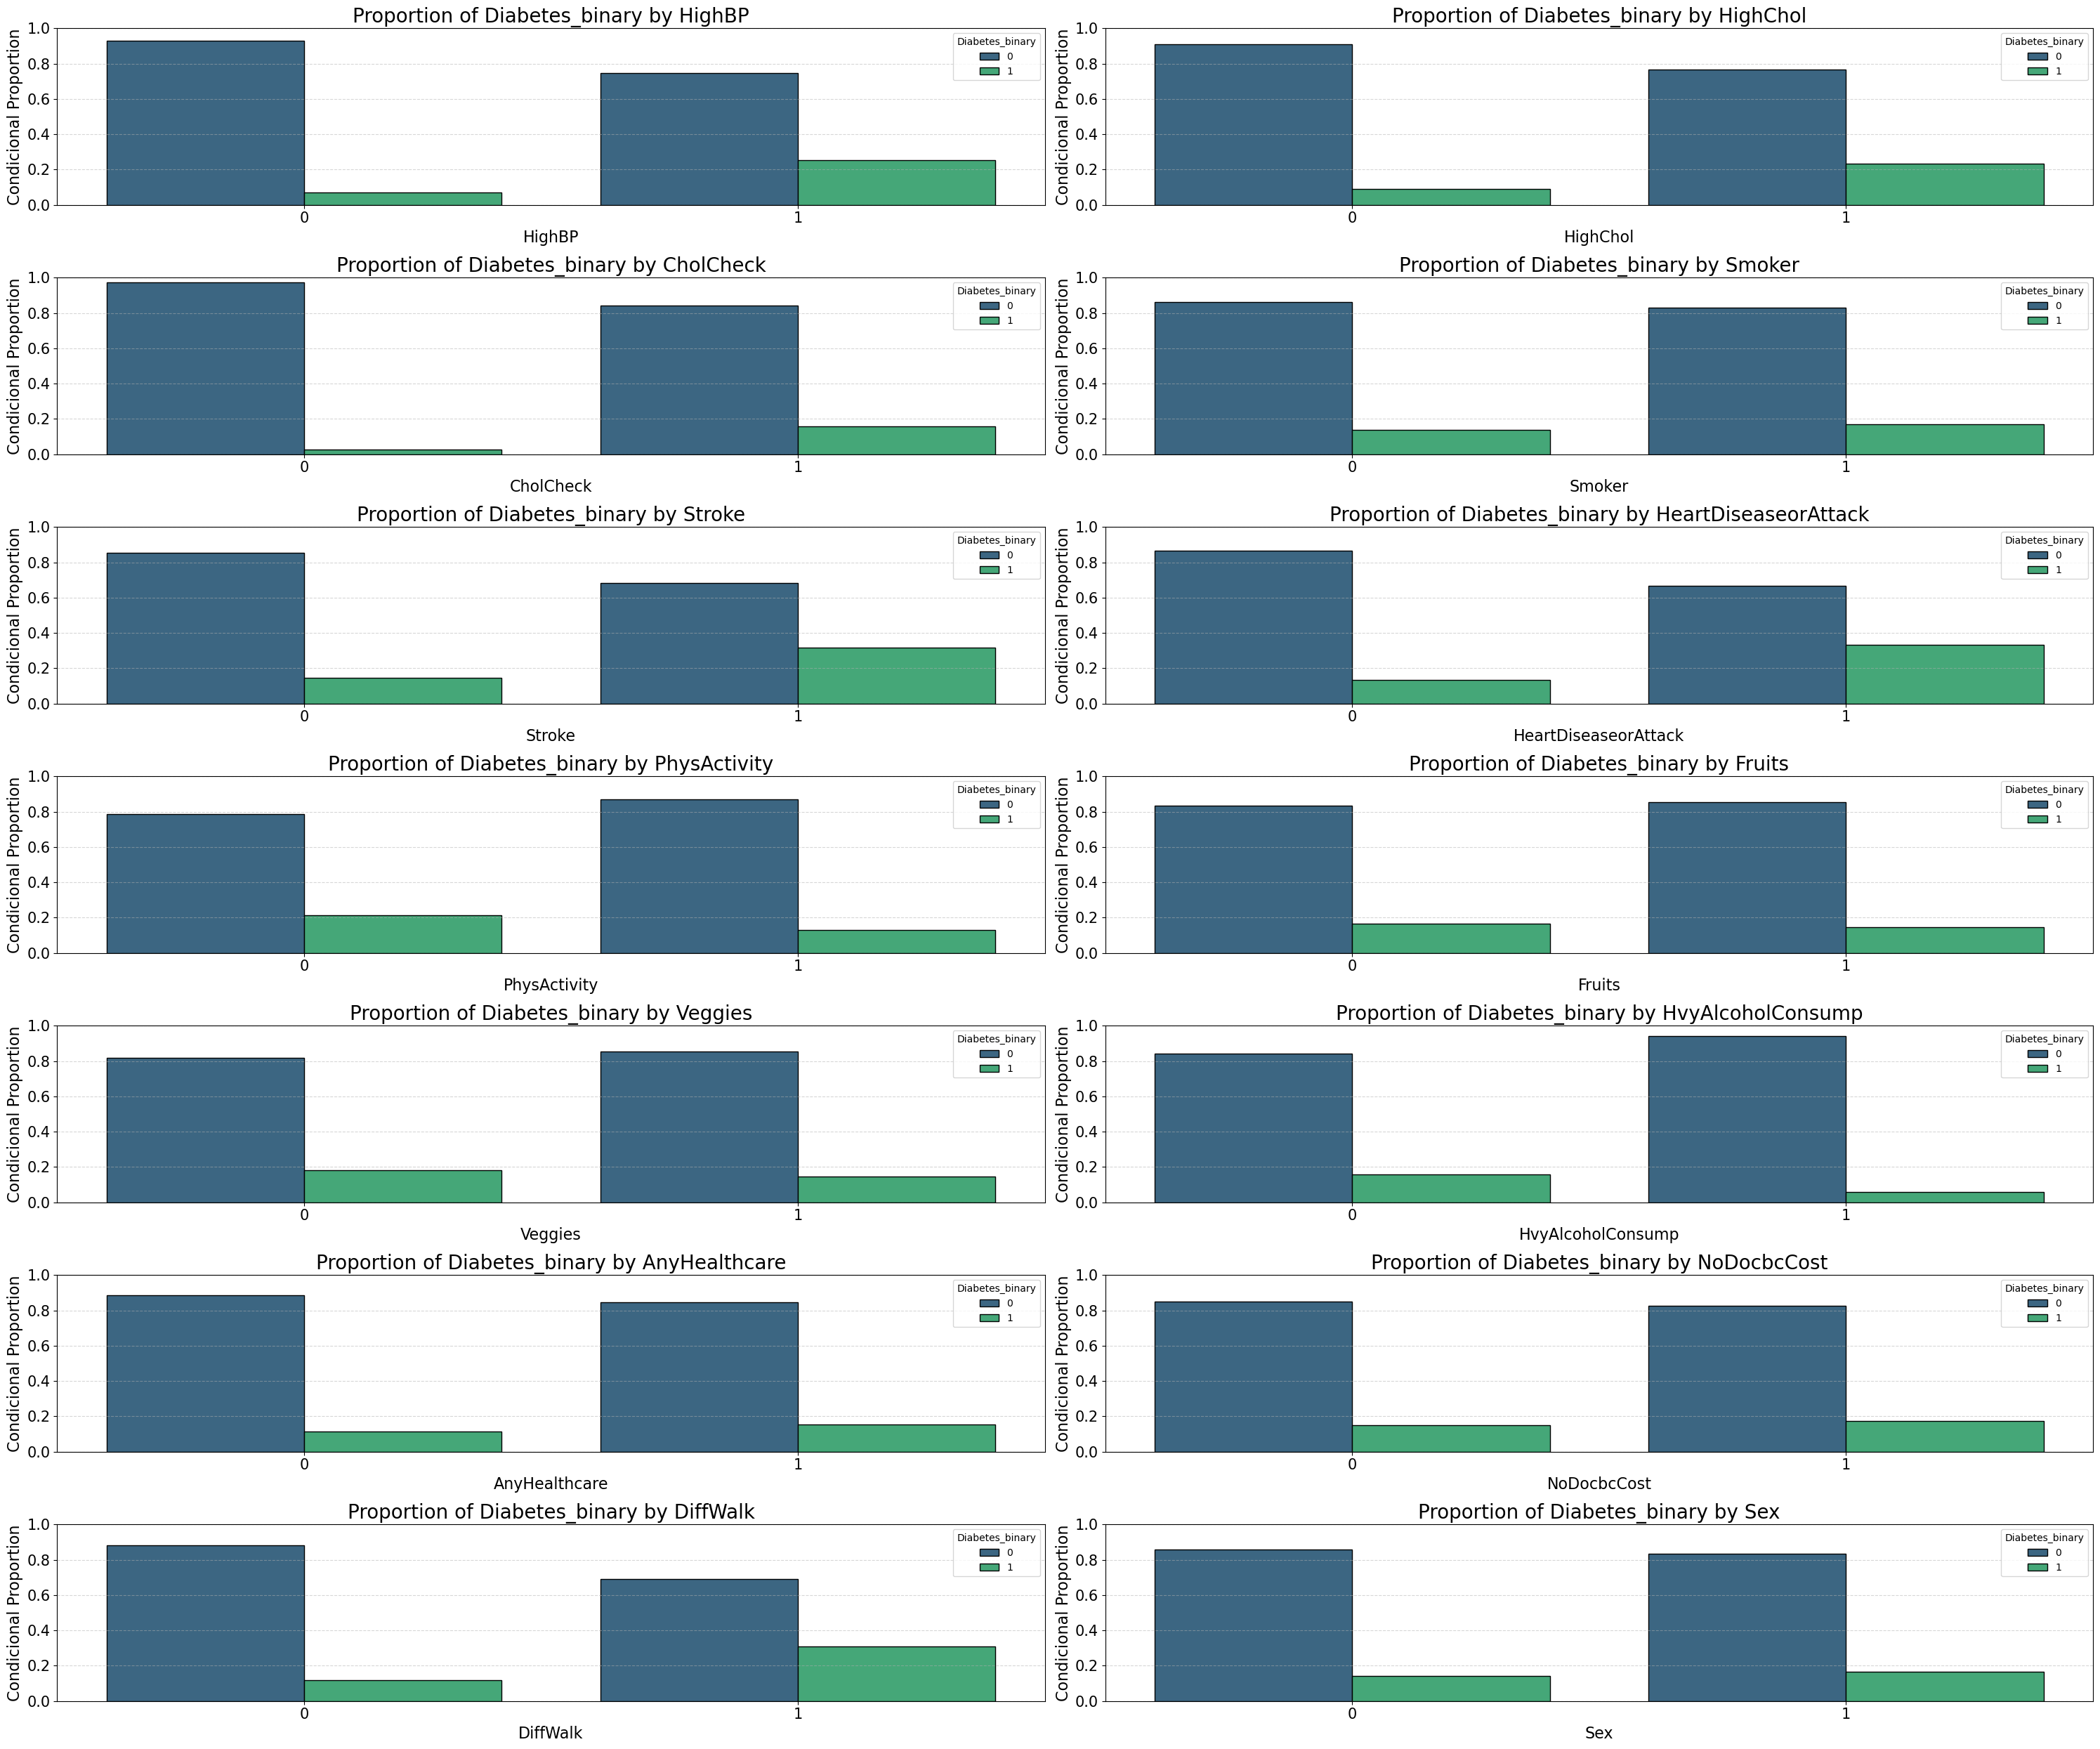

In [19]:
fig, axes = plt.subplots(7, 2, figsize=(30, 25))
axes = axes.flatten()

for ax, col in zip(axes, cols_bin):

    # Tabela de proporções condicionais
    prop = (
        df_eda
        .groupby(col)[target]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )

    sns.barplot(
        data=prop,
        x=col,
        y="proportion",
        hue=target,
        palette="viridis",
        ax=ax,
        edgecolor="black"
    )

    ax.set_title(f"Proportion of {target} by {col}", fontsize=20)
    ax.set_xlabel(col, fontsize=16)
    ax.set_ylabel("Condicional Proportion", fontsize=16)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params("x", labelsize=15)
    ax.tick_params("y", labelsize=15)

# Remover axes excedentes
for ax in axes[len(cols_bin):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Relação da variável target com as variáveis ordinais

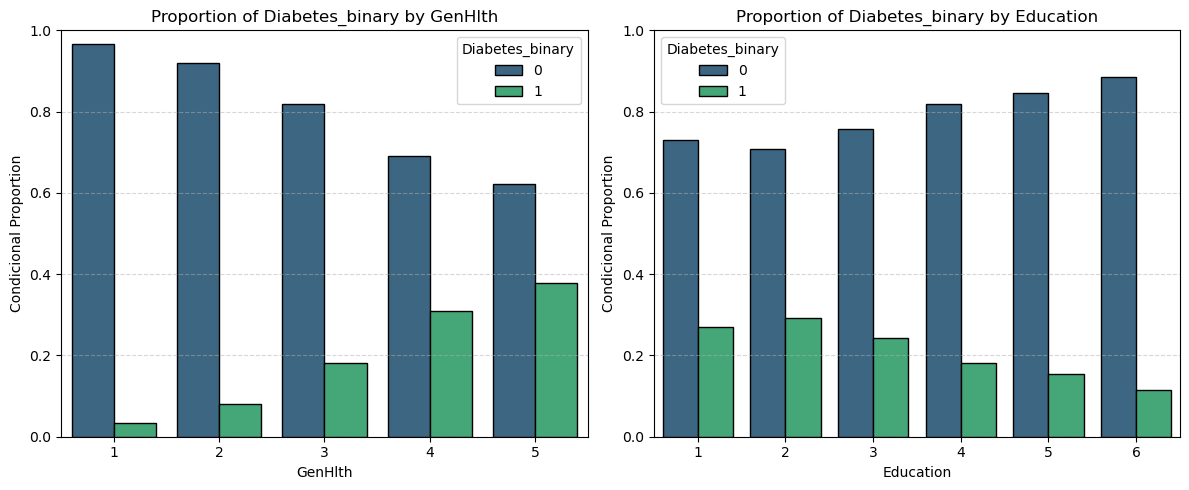

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for ax, col in zip(axes, cols_ordinal):

    # Tabela de proporções condicionais
    prop = (
        df_eda
        .groupby(col)[target]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )

    sns.barplot(
        data=prop,
        x=col,
        y="proportion",
        hue=target,
        palette="viridis",
        ax=ax,
        edgecolor="black"
    )

    ax.set_title(f"Proportion of {target} by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Condicional Proportion")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params("x")
    ax.tick_params("y")

# Remover axes excedentes
for ax in axes[len(cols_ordinal):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Relação da variável target com as variáveis semiordinais

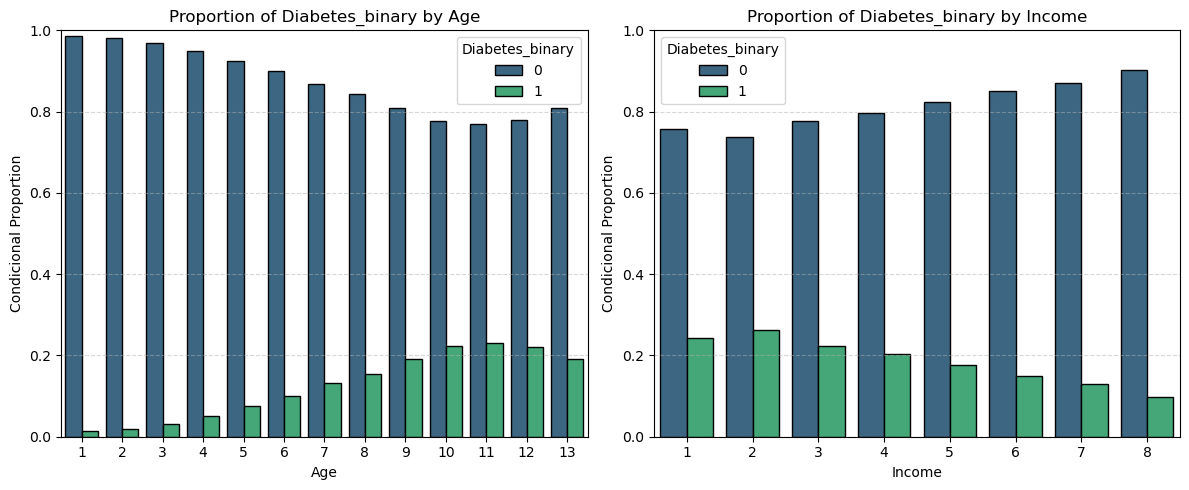

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for ax, col in zip(axes, cols_semior):

    # Tabela de proporções condicionais
    prop = (
        df_eda
        .groupby(col)[target]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )

    sns.barplot(
        data=prop,
        x=col,
        y="proportion",
        hue=target,
        palette="viridis",
        ax=ax,
        edgecolor="black"
    )

    ax.set_title(f"Proportion of {target} by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Condicional Proportion")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params("x")
    ax.tick_params("y")

# Remover axes excedentes
for ax in axes[len(cols_semior):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Relação da variável target com as variáveis numéricas

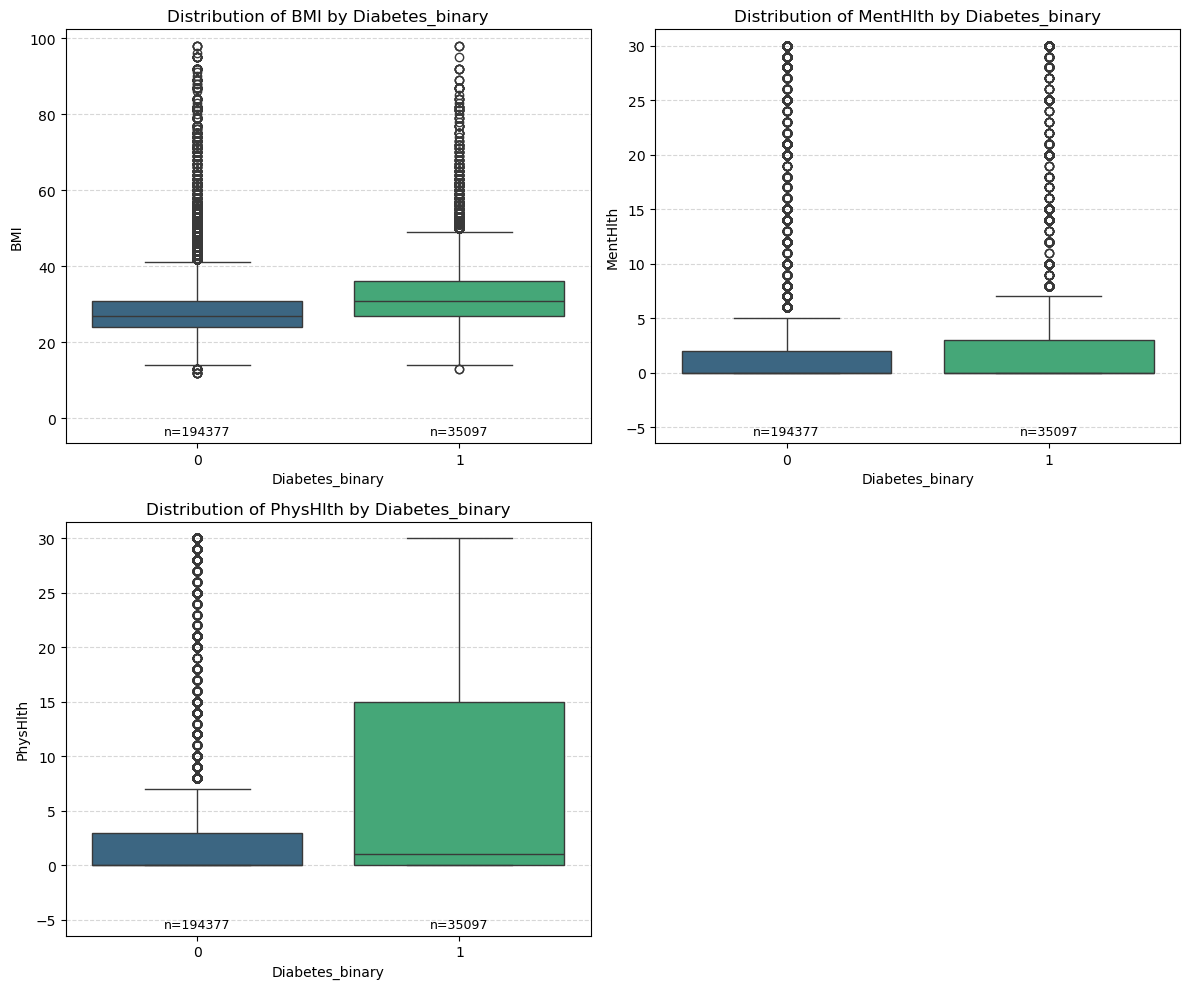

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols_numeric):

    # Boxplot estratificado
    sns.boxplot(
        data=df_eda,
        x=target,
        y=col,
        palette="viridis",
        ax=ax
    )

    # Contagem por classe (ordenada)
    counts = df_eda[target].value_counts().sort_index()

    # Limites atuais do eixo Y
    ymin, ymax = ax.get_ylim()
    y_range = ymax - ymin

    # Offset para posicionar o texto fora da área dos dados
    offset = 0.10 * y_range

    # Inserir n abaixo de cada categoria
    for i, cls in enumerate(counts.index):
        ax.text(
            i,
            ymin - offset,
            f"n={counts[cls]}",
            ha="center",
            va="top",
            fontsize=9
        )

    # Expandir o eixo Y inferior para não cortar o texto
    ax.set_ylim(ymin - 1.5 * offset, ymax)

    # Ajustes visuais
    ax.set_title(f"Distribution of {col} by {target}")
    ax.set_xlabel(target)
    ax.set_ylabel(col)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Remover axes extras, se houver
for ax in axes[len(cols_numeric):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Correlação 

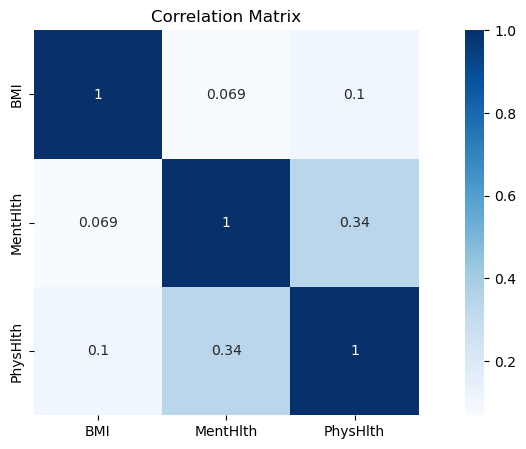

In [23]:
corr = df[cols_numeric].corr()
plt.figure(figsize=(12,5))
plt.title("Correlation Matrix")
sns.heatmap(corr, vmax=1, annot=True, square=True, cmap="Blues");

* Associação (categórica vs categórica)

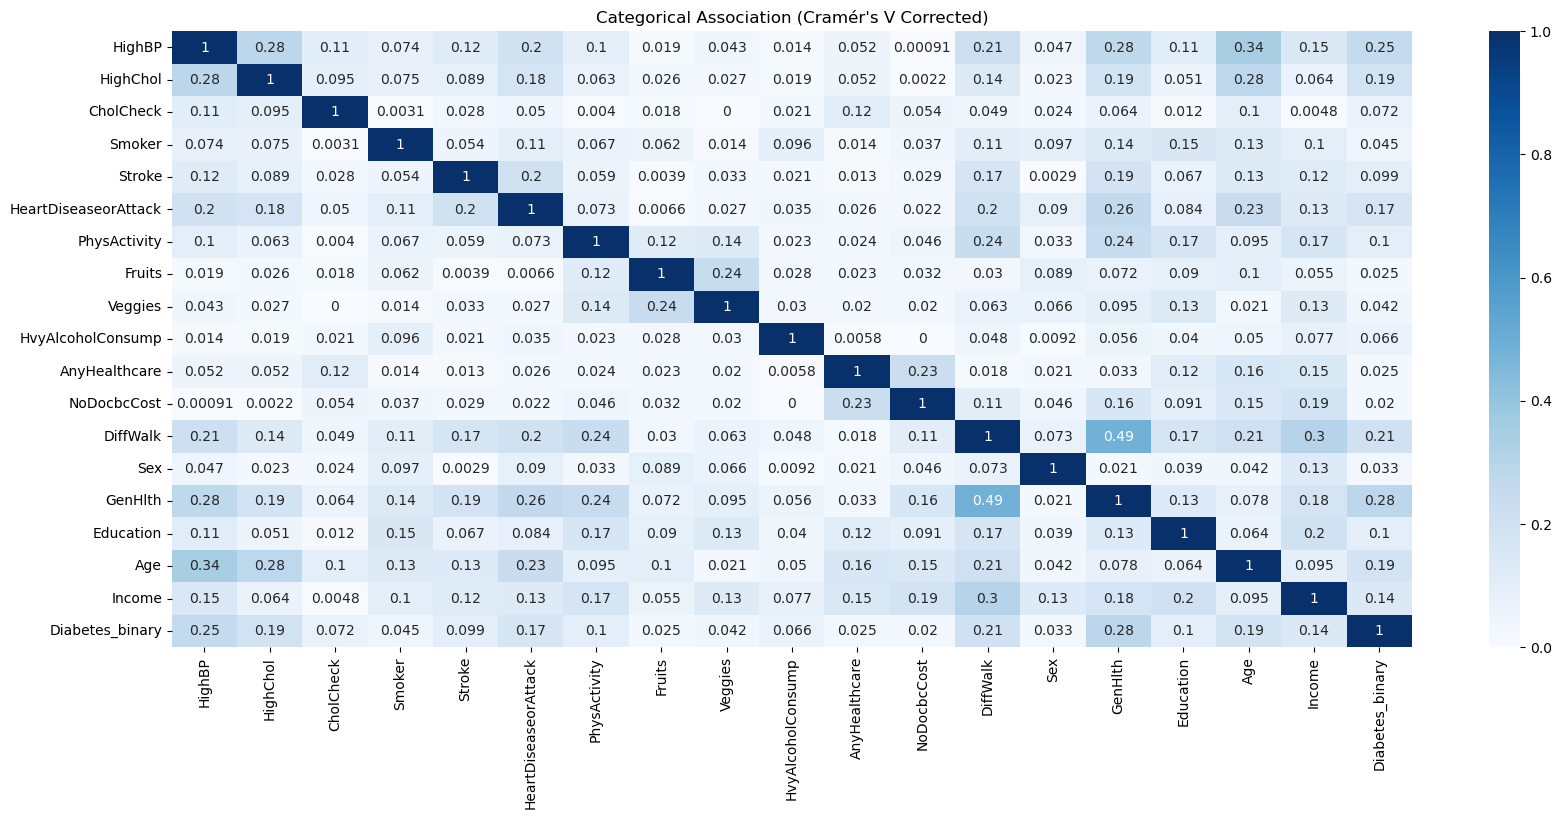

In [24]:
def cramers_v_corrected(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Correction
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1))/(n - 1))
    rcorr = r - (r - 1)**2 / (n - 1)
    kcorr = k - (k - 1)**2 / (n - 1)

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

cols_v = cols_bin + cols_ordinal + cols_semior + [target]

mat = pd.DataFrame(index=cols_v, columns=cols_v)

for c1 in cols_v:
    for c2 in cols_v:
        tab = pd.crosstab(df[c1], df[c2])
        mat.loc[c1, c2] = cramers_v_corrected(tab.values)

plt.figure(figsize=(20,8))
sns.heatmap(mat.astype(float), annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title("Categorical Association (Cramér's V Corrected)")
plt.show()

* Data leakage

In [110]:
leakage_features = []


def leakage_mi_permutation_test(
    df,
    feature,
    target="Diabetes_binary",
    n_permutations=20,
    random_state=42
):
    # Checagem mínima
    if feature not in df.columns or target not in df.columns:
        raise ValueError("Feature ou target inexistente.")

    df_local = df[[feature, target]].dropna()

    X = df_local[[feature]]
    y = df_local[target]

    # MI real
    mi_real = mutual_info_classif(
        X, y,
        discrete_features="auto",
        random_state=random_state
    )[0]

    # MI sob permutação do target
    rng = np.random.RandomState(random_state)
    mi_perm = []

    for _ in range(n_permutations):
        y_perm = rng.permutation(y)
        mi_p = mutual_info_classif(
            X, y_perm,
            discrete_features="auto",
            random_state=random_state
        )[0]
        mi_perm.append(mi_p)

    mi_perm = np.array(mi_perm)

    delta = mi_real - mi_perm.mean()
    z_score = delta / (mi_perm.std() + 1e-8)

    return {
        "feature": feature,
        "mi_real": mi_real,
        "mi_perm_mean": mi_perm.mean(),
        "delta_mi": delta,
        "z_score": z_score
    }


In [111]:
result = leakage_mi_permutation_test(df_eda, feature="MentHlth") # feature = variável suspeita

if result["z_score"] > 5:
    leakage_features.append("MentHlth")
    
print(f"Feature causing leakage: {leakage_features}")

Feature causing leakage: ['MentHlth']


In [112]:
result = leakage_mi_permutation_test(df_eda, feature="PhysHlth") # feature = variável suspeita

if result["z_score"] > 5:
    leakage_features.append("PhysHlth")
    
print(f"Feature causing leakage: {leakage_features}")

Feature causing leakage: ['MentHlth', 'PhysHlth']


# Pré-processamento

* Dataset para pré-processamento

In [25]:
df_prep = df_eda.copy()

* Features irrelevantes

In [26]:
# Features relacionadas a leakage
irrelevant_features=["MentHlth", "PhysHlth"]

df_prep = df_prep.drop(columns=irrelevant_features).reset_index(drop=True)

* Pré-processador

In [27]:
cols_bin = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack", "PhysActivity",
            "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex"]

cols_ordinal = ["GenHlth", "Education"]

cols_semior = ["Age", "Income"]

cols_numeric = ["BMI"]

target = "Diabetes_binary"

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("bin", "passthrough", cols_bin),               # binárias → ok
        ("ord", "passthrough", cols_ordinal),           # ordinais → ok
        ("ohe", OneHotEncoder(drop="first"), cols_semior), # AGE & INCOME → OHE
        ("num", StandardScaler(), cols_numeric),        # BMI → scaling
    ],
    remainder="drop"
)

* Separar X e Y

In [29]:
X = df_prep.drop(columns = ['Diabetes_binary'])
y = df_prep['Diabetes_binary']

* Dividir em treino/teste

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

* Seleção de Features 

In [47]:
pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),                     # já tem scaler
    ("feature_selection", SelectKBest(score_func=mutual_info_classif, k="all")), # score=chi2 não funciona com dados padronizados
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bin', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

# Treinamento e Avaliação de Modelos Base

* Criar um Avaliador Universal

In [48]:
def evaluate_model(name, pipeline, X_test, y_test):
    """
    Avaliador para o Dataset CDC Diabetes (Sem reamostragem).
    Focado em métricas de separação probabilística.
    """
    print(f"\n{'='*40}\nMODEL: {name}\n{'='*40}")

    # 1. Predição de Probabilidades (Sempre o primeiro passo para avaliação técnica)
    # O pipeline já cuida do transform(X_test) internamente
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # 2. Predição de Classe (Threshold padrão 0.5)
    y_pred = pipeline.predict(X_test)

    # 3. Métricas de Performance (Cruciais para desbalanceamento moderado)
    roc_auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    
    print(f"ROC-AUC SCORE: {roc_auc:.4f}")
    print(f"AVERAGE PRECISION (AP): {ap:.4f}")
    print("\nCLASSIFICATION REPORT (Threshold 0.50):")
    print(classification_report(y_test, y_pred))

    # 4. Matriz de Confusão Visual para o relatório
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

    return {"name": name, "roc_auc": roc_auc, "ap": ap, "y_proba": y_proba}

* Pipeline para cada modelo

In [49]:
# 1. Instanciar e ajustar o LabelEncoder no alvo (target)
le = LabelEncoder()

# 2. Transformar y_train e y_test (Garante que Diabetes=1 e Saudável=0)
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)

# 3. Recalcular os pesos para o XGBoost usando o y_train numérico
pesos_treino = compute_sample_weight(class_weight='balanced', y=y_train_num)

# 4. Conferir o mapeamento
print(f"Map: {dict(zip(le.classes_, range(len(le.classes_))))}")

Map: {np.int64(0): 0, np.int64(1): 1}



MODEL: Baseline (Naive)
ROC-AUC SCORE: 0.5000
AVERAGE PRECISION (AP): 0.1529

CLASSIFICATION REPORT (Threshold 0.50):
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     38876
           1       0.00      0.00      0.00      7019

    accuracy                           0.85     45895
   macro avg       0.42      0.50      0.46     45895
weighted avg       0.72      0.85      0.78     45895



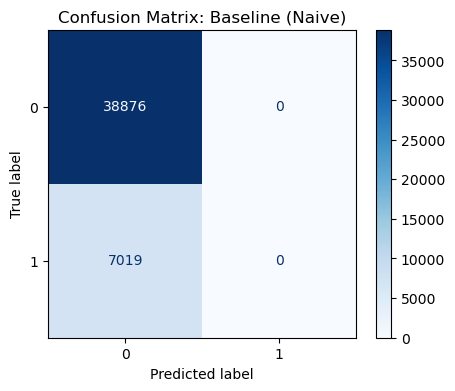


MODEL: Regressão Logística
ROC-AUC SCORE: 0.8124
AVERAGE PRECISION (AP): 0.4206

CLASSIFICATION REPORT (Threshold 0.50):
              precision    recall  f1-score   support

           0       0.94      0.71      0.81     38876
           1       0.32      0.76      0.45      7019

    accuracy                           0.72     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.72      0.75     45895



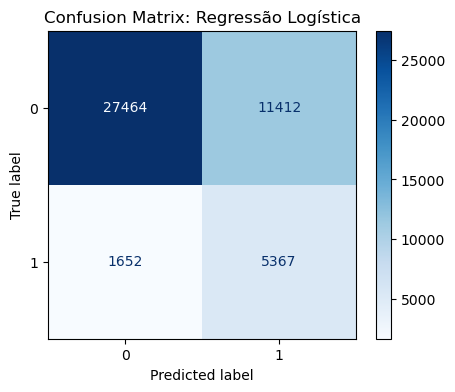


MODEL: Random Forest
ROC-AUC SCORE: 0.7603
AVERAGE PRECISION (AP): 0.3283

CLASSIFICATION REPORT (Threshold 0.50):
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     38876
           1       0.40      0.18      0.25      7019

    accuracy                           0.83     45895
   macro avg       0.63      0.57      0.58     45895
weighted avg       0.79      0.83      0.81     45895



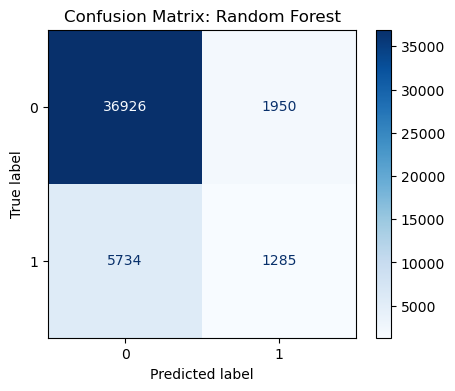


MODEL: XGBoost
ROC-AUC SCORE: 0.8108
AVERAGE PRECISION (AP): 0.4300

CLASSIFICATION REPORT (Threshold 0.50):
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     38876
           1       0.32      0.77      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.71      0.75     45895



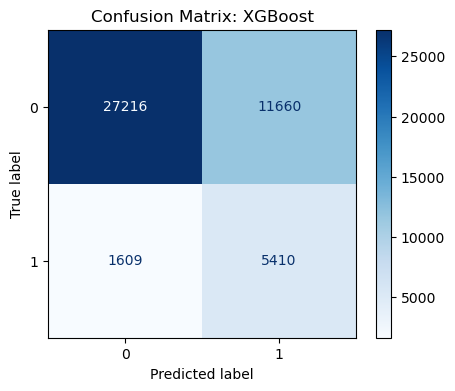

[LightGBM] [Info] Number of positive: 28078, number of negative: 155501
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 155
[LightGBM] [Info] Number of data points in the train set: 183579, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

MODEL: LGBM
ROC-AUC SCORE: 0.8168
AVERAGE PRECISION (AP): 0.4422

CLASSIFICATION REPORT (Threshold 0.50):
              precision    recall  f1-score   support

           0       0.95      0.69      0.80     38876
           1       0.32      0.79      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.71      0.75     45895



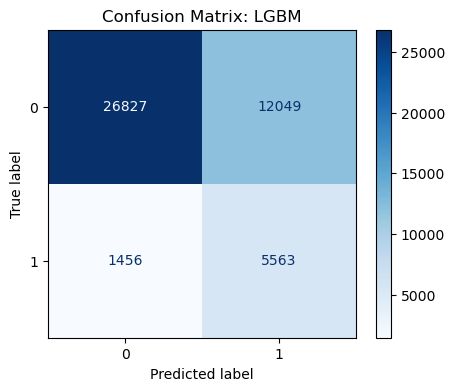

{'name': 'LGBM',
 'roc_auc': 0.8168069830919592,
 'ap': 0.4421786735789712,
 'y_proba': array([0.67360225, 0.0341592 , 0.36384847, ..., 0.45200326, 0.09293827,
        0.41067707], shape=(45895,))}

In [50]:
# 1. Dummy
dummy_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent", random_state=42))
])

dummy_pipe.fit(X_train, y_train_num)
evaluate_model("Baseline (Naive)", dummy_pipe, X_test, y_test_num)

# 2. Logistic Regression
logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_pipe.fit(X_train, y_train_num)
evaluate_model("Regressão Logística", logreg_pipe, X_test, y_test_num)

# 3. Random Forest
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

rf_pipe.fit(X_train, y_train_num)
evaluate_model("Random Forest", rf_pipe, X_test, y_test_num)

# 4. XGBoost 
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        objective='binary:logistic',  
        random_state=42,
        verbosity=0
    ))
])

xgb_pipe.fit(X_train, y_train_num, model__sample_weight=pesos_treino)
evaluate_model("XGBoost", xgb_pipe, X_test, y_test_num)

# 5. LGBM
lgbm_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LGBMClassifier(
        random_state=42,
        class_weight="balanced",                
    ))
])

lgbm_pipe.fit(X_train, y_train_num)
evaluate_model("LGBM", lgbm_pipe, X_test, y_test_num)

In [51]:
def get_metrics(model, X_test, y_test):
    # Predição das classes
    y_pred = model.predict(X_test)

    # Predição das probabilidades
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]  
    else:
        y_proba = None

    # --- MÉTRICAS PRIORITÁRIAS ---
    # AP: Melhor para dados desbalanceados (mede a área sob a curva Precision-Recall)
    ap = average_precision_score(y_test, y_proba) if y_proba is not None else 0
    
    # AUC: Mede a capacidade de separação global
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 0
    
    # RECALL (Classe 1): Quão bom o modelo é em achar os diabéticos?
    # Em saúde, o falso negativo é mais perigoso que o falso positivo.
    recall_pos = recall_score(y_test, y_pred)
    
    # F1-Score da Classe 1: O equilíbrio para a classe que nos interessa
    f1_pos = f1_score(y_test, y_pred)

    return ap, auc, recall_pos, f1_pos

In [52]:
results = []

# Dicionário com todos os pipelines que você treinou
models = {
    "Baseline (Naive)": dummy_pipe,
    "Logistic Regression": logreg_pipe,
    "Random Forest": rf_pipe,
    "XGBoost": xgb_pipe,
    "LGBM": lgbm_pipe
}

for name, model in models.items():
    ap, auc, recall, f1 = get_metrics(model, X_test, y_test_num)
    results.append([name, ap, auc, recall, f1])

# Criando o DataFrame de Resultados
df_results = pd.DataFrame(results, columns=["Model", "Avg Precision", "ROC-AUC", "Recall (Pos)", "F1-Score (Pos)"])

# Ordenando pela Average Precision
df_results.sort_values("Avg Precision", ascending=False, inplace=True)
df_results

,Model,Avg Precision,ROC-AUC,Recall (Pos),F1-Score (Pos)
4,LGBM,0.442179,0.816807,0.792563,0.451707
3,XGBoost,0.429954,0.810840,0.770765,0.449168
1,Logistic Regression,0.420553,0.812359,0.764639,0.451046
2,Random Forest,0.328258,0.760262,0.183075,0.250634
0,Baseline (Naive),0.152936,0.500000,0.000000,0.000000


# Modelos Promissores

In [53]:
# Criar um diretório temporário para cache
cachedir = mkdtemp()

* LGBM

In [63]:
# Pipeline com Cache
lgbm_pipe_grid = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LGBMClassifier(random_state=42))
], memory=cachedir)

# Grid para LGBM: Foco em folhas e regularização
param_grid_lgbm = {
    'model__n_estimators': [200, 500],
    'model__num_leaves': [63, 127],              # Dobramos a complexidade das folhas
    'model__max_depth': [-1, 10],                # -1 significa sem limite (controlado por num_leaves)
    'model__learning_rate': [0.01, 0.05],
    'model__min_child_samples': [20, 50],        # Evita folhas com poucos dados
    'model__class_weight': ['balanced', None]    # Testamos se o peso automático é melhor que o padrão
}

grid_lgbm = RandomizedSearchCV(
    lgbm_pipe_grid, 
    param_grid_lgbm, 
    cv=3, 
    scoring='average_precision', 
    n_jobs=-1
)

print("Starting Search LGBM...")
grid_lgbm.fit(X_train, y_train_num)

Starting Search LGBM...
[LightGBM] [Info] Number of positive: 28078, number of negative: 155501
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 155
[LightGBM] [Info] Number of data points in the train set: 183579, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(memo...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': ['balanced', None], 'model__learning_rate': [0.01, 0.05], 'model__max_depth': [-1, 10], 'model__min_child_samples': [20, 50], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation 

* XGBoost

In [64]:
# Pipeline com Cache
xgb_pipe_grid = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(objective='binary:logistic', random_state=42, verbosity=0))
], memory=cachedir)

# Grid para XGBoost: Foco em profundidade e regularização
param_grid_xgb = {
    'model__n_estimators': [200, 500],           # Aumentamos para dar mais fôlego
    'model__max_depth': [6, 8],                  # Árvores mais profundas para captar interações
    'model__learning_rate': [0.01, 0.05],        # Menor learning rate exige mais árvores
    'model__subsample': [0.8],                   # Evita overfitting treinando com 80% das linhas
    'model__colsample_bytree': [0.8],            # Treina com 80% das colunas por árvore
    'model__scale_pos_weight': [3, 5, 7]         # Testamos níveis diferentes de agressividade
}
    

grid_xgb = RandomizedSearchCV(
    xgb_pipe_grid, 
    param_grid_xgb, 
    cv=3, 
    scoring='average_precision', # Foco em dados desbalanceados
    n_jobs=-1
)

print("Starting Search XGBoost...")
grid_xgb.fit(X_train, y_train_num)

Starting Search XGBoost...


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(memo...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8], 'model__learning_rate': [0.01, 0.05], 'model__max_depth': [6, 8], 'model__n_estimators': [200, 500], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies t

* Comparação dos modelos promissores

In [65]:
# Dicionário atualizado com os melhores modelos do GridSearch
models_optimized = {
    "XGBoost (Tuned)": grid_xgb.best_estimator_,
    "LGBM (Tuned)": grid_lgbm.best_estimator_
}

results_opt = []

# Usando a função get_metrics adaptada para saúde que criamos antes
for name, model in models_optimized.items():
    ap, auc, recall, f1 = get_metrics(model, X_test, y_test_num)
    results_opt.append([name, ap, auc, recall, f1])

# DataFrame com as métricas prioritárias
df_results_opt = pd.DataFrame(
    results_opt, 
    columns=["Modelo", "Avg Precision (AP)", "ROC-AUC", "Recall (Pos)", "F1-Score (Pos)"]
)

# Ordenação pelo "padrão ouro" de dados desbalanceados (Average Precision)
df_results_opt.sort_values("Avg Precision (AP)", ascending=False, inplace=True)
df_results_opt

,Modelo,Avg Precision (AP),ROC-AUC,Recall (Pos),F1-Score (Pos)
0,XGBoost (Tuned),0.444570,0.817270,0.755948,0.46045
1,LGBM (Tuned),0.442138,0.816569,0.788146,0.45161


# Análise de Erros e Interpretação do Modelo Final

* Análise de Thresholds Clínicos (Ponto de Corte)

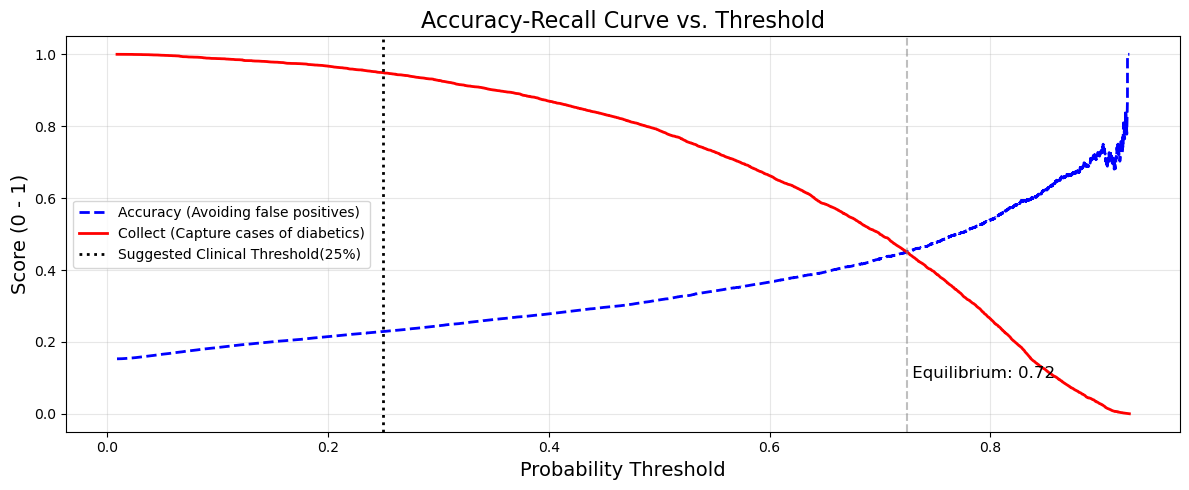

In [98]:
# 1. Obter probabilidades para a classe positiva (Diabetes - índice 1)
y_proba = grid_lgbm.best_estimator_.predict_proba(X_test)[:, 1]

# 2. Calcular precision e recall
precision, recall, thresholds = precision_recall_curve(y_test_num, y_proba)

plt.figure(figsize=(12, 5))

# Plotar as curvas
plt.plot(thresholds, precision[:-1], 'b--', label='Accuracy (Avoiding false positives)', linewidth=2)
plt.plot(thresholds, recall[:-1], 'r-', label='Collect (Capture cases of diabetics)', linewidth=2)

# Encontrar o ponto de equilíbrio (onde se cruzam)
# (Opcional: apenas para referência visual)
idx = np.argwhere(np.diff(np.sign(precision - recall))).flatten()
if len(idx) > 0:
    plt.axvline(thresholds[idx[0]], color='gray', linestyle='--', alpha=0.5)
    plt.text(thresholds[idx[0]], 0.1, f' Equilibrium: {thresholds[idx[0]]:.2f}', fontsize=12)

# 2. Marcar o Threshold de Negócio Sugerido
# Para o CDC, um valor entre 0.2 e 0.3 costuma ser excelente para Recall alto
threshold_clinico = 0.25 
plt.axvline(threshold_clinico, color='black', linestyle=':', label=f'Suggested Clinical Threshold({threshold_clinico*100:.0f}%)', linewidth=2)

plt.title('Accuracy-Recall Curve vs. Threshold', fontsize=16)
plt.xlabel('Probability Threshold',fontsize=14)
plt.ylabel('Score (0 - 1)',fontsize=14)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()

# plt.savefig("Curvas Precision-Recall.svg", format="svg")

plt.show()

* Probabilidades preditas e calibração

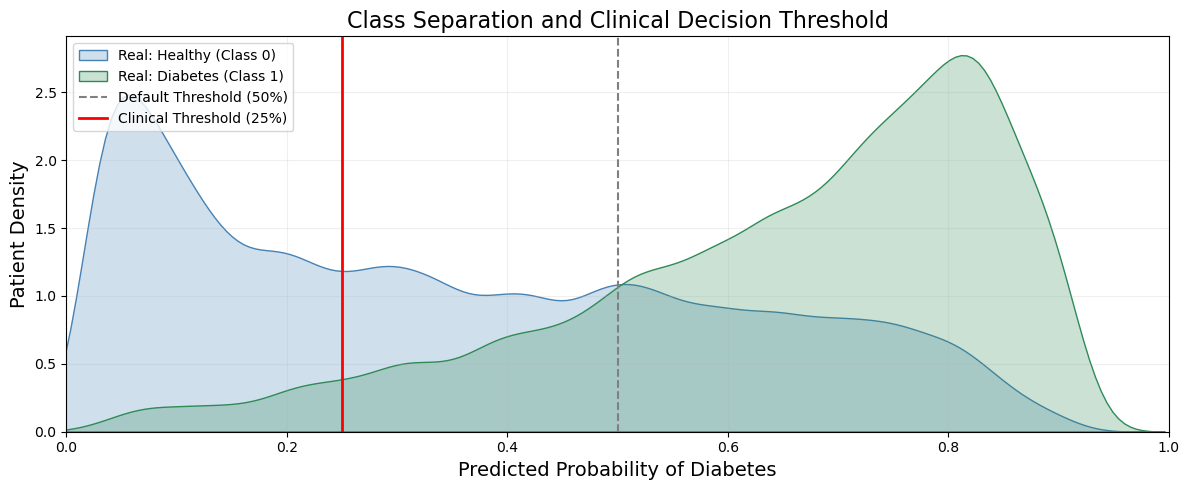

In [95]:
plt.figure(figsize=(12, 5))

# 1. Distribuição para quem REALMENTE não tem diabetes (Classe 0)
sns.kdeplot(
    y_proba[y_test_num == 0],
    fill=True,
    color="steelblue",
    label="Real: Healthy (Class 0)",
    bw_adjust=0.7
)

# 2. Distribuição para quem REALMENTE tem diabetes (Classe 1)
sns.kdeplot(
    y_proba[y_test_num == 1],
    fill=True,
    color="seagreen",
    label="Real: Diabetes (Class 1)",
    bw_adjust=0.7
)

# 3. Linhas de Threshold para Comparação
plt.axvline(0.5, color="gray", linestyle="--", label="Default Threshold (50%)")
plt.axvline(0.25, color="red", linestyle="-", linewidth=2, label="Clinical Threshold (25%)")

# 4. Formatação 
plt.title("Class Separation and Clinical Decision Threshold", fontsize=16)
plt.xlabel("Predicted Probability of Diabetes", fontsize=14)
plt.ylabel("Patient Density", fontsize=14)
plt.xlim(0, 1)
plt.legend(loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()

# plt.savefig("Separação de Classes.svg", format="svg")

plt.show()

* Calibração

Brier Score (Diabetes): 0.1820


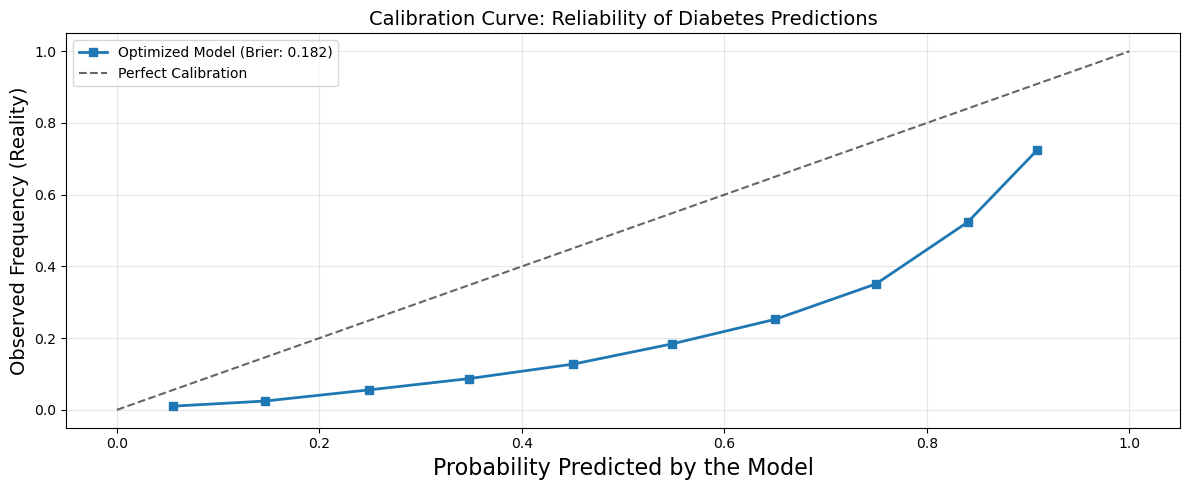

In [90]:
# 1. Calcular a Curva de Calibração
# n_bins=10 divide as probabilidades em fatias de 10%
prob_true, prob_pred = calibration_curve(y_test_num, y_proba, n_bins=10)

# 2. Calcular Brier Score (Quanto menor, melhor a calibração)
brier = brier_score_loss(y_test_num, y_proba)
print(f"Brier Score (Diabetes): {brier:.4f}")

# 3. Plotagem
plt.figure(figsize=(12, 5))
plt.plot(prob_pred, prob_true, marker='s', linewidth=2, label=f'Optimized Model (Brier: {brier:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.6, label='Perfect Calibration')

plt.xlabel('Probability Predicted by the Model', fontsize=16)
plt.ylabel('Observed Frequency (Reality)', fontsize=14)
plt.title('Calibration Curve: Reliability of Diabetes Predictions', fontsize=14)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()

# plt.savefig("Brier Score.svg", format="svg")

plt.show()

* Curva ROC-AUC

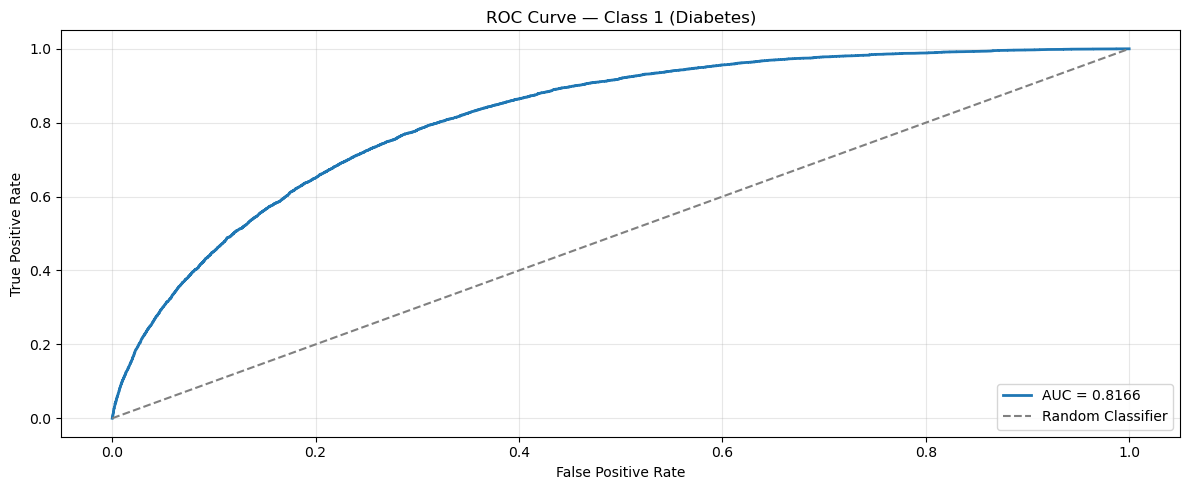

In [87]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# AUC
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(12, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Class 1 (Diabetes)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* Matriz de confusão

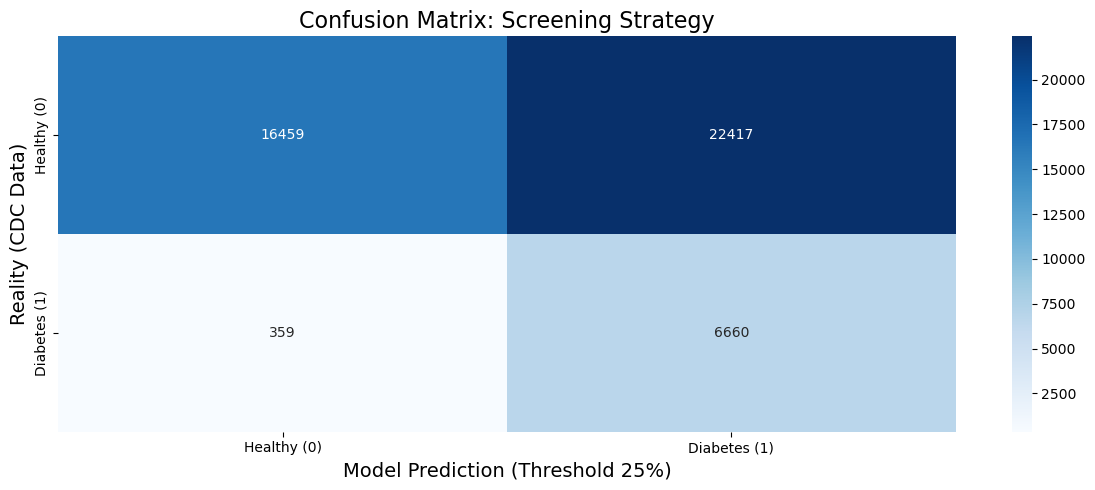

Sensitivity (Recall): 94.89%
Diabetes cases identified: 6660
Missed Diabetes Cases (False Negatives): 359


In [89]:
# 1. Aplicar o Threshold Clínico de 0.25 (definido nas análises anteriores)
# Isso transforma probabilidades em classes (0 ou 1)
y_pred_clinico = (y_proba >= 0.25).astype(int)

# 2. Gerar a Matriz de Confusão
cm = confusion_matrix(y_test_num, y_pred_clinico)

# 3. Plotagem 
plt.figure(figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Healthy (0)', 'Diabetes (1)'], 
            yticklabels=['Healthy (0)', 'Diabetes (1)'])

plt.xlabel("Model Prediction (Threshold 25%)", fontsize=14)
plt.ylabel("Reality (CDC Data)", fontsize=14)
plt.title("Confusion Matrix: Screening Strategy", fontsize=16)
plt.tight_layout()

# plt.savefig("Matriz de Confusão.svg", format="svg")

plt.show()

# 4. Extração de Métricas de Negócio
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn)
print(f"Sensitivity (Recall): {recall:.2%}")
print(f"Diabetes cases identified: {tp}")
print(f"Missed Diabetes Cases (False Negatives): {fn}")

* Shap summary

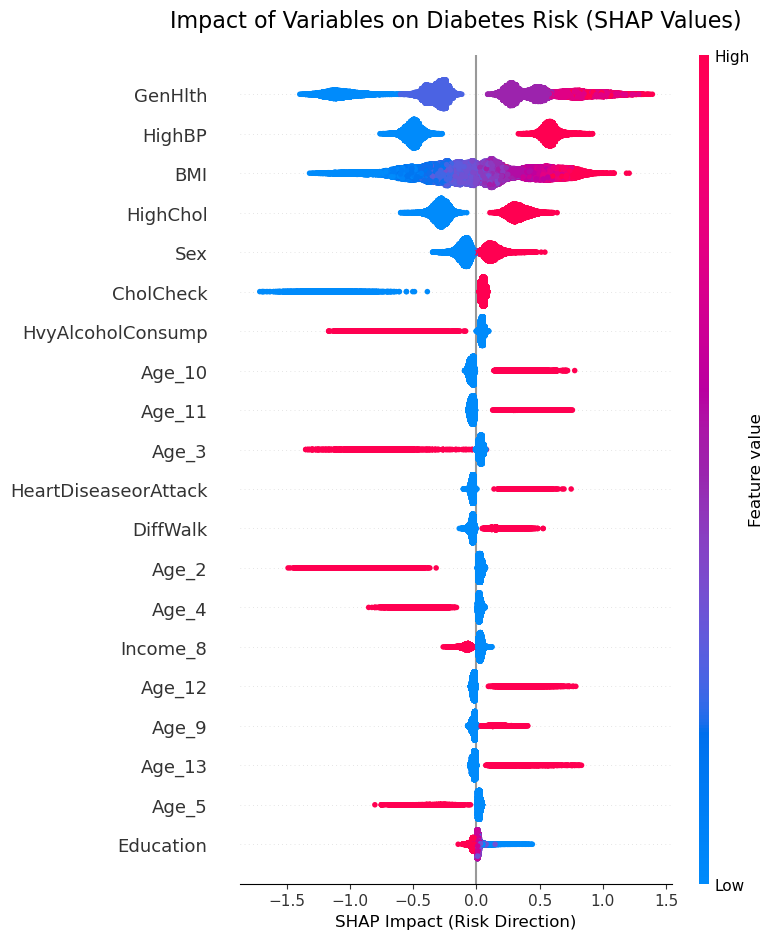

In [71]:
# ==============================================================================
# 1. PREPARAÇÃO DO DATAFRAME COM NOMES LIMPOS
# ==============================================================================

# Recuperar o pré-processador e o modelo do pipeline
# (Ajuste 'grid_xgb' para o nome da variável do RandomGridSearchCV)
preprocessor_step = grid_lgbm.best_estimator_.named_steps['preprocess']
classifier_model = grid_lgbm.best_estimator_.named_steps['model']

# Transformar o X_test e recuperar os nomes originais das colunas
X_test_transformed = preprocessor_step.transform(X_test)
feature_names_raw = preprocessor_step.get_feature_names_out()

# Criar o DataFrame para o SHAP
df_shap = pd.DataFrame(X_test_transformed, columns=feature_names_raw)

# --- LIMPEZA DOS NOMES (Removendo prefixos bin__, ord__, num__, ohe__) ---
# O regex r'^.*__' remove tudo desde o início até o duplo underscore
df_shap.columns = df_shap.columns.str.replace(r'^.*__', '', regex=True)

# ==============================================================================
# 2. CÁLCULO DO SHAP VALUES
# ==============================================================================

# Criar o explicador otimizado para árvores (XGBoost/LGBM)
explainer = shap.TreeExplainer(classifier_model)

# Calcular os valores SHAP
# check_additivity=False evita erros comuns com modelos complexos em bases grandes
shap_values = explainer.shap_values(df_shap, check_additivity=False)

# Garantir que estamos pegando os valores da classe 1 (Diabetes)
# Dependendo da versão do SHAP/XGBoost, o retorno pode variar de formato
if isinstance(shap_values, list):
    shap_values_target = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_target = shap_values[:, :, 1]
else:
    shap_values_target = shap_values

# ==============================================================================
# 3. PLOTAGEM DO SUMMARY PLOT 
# ==============================================================================

plt.figure(figsize=(12, 10))
plt.title("Impact of Variables on Diabetes Risk (SHAP Values)", fontsize=16, pad=20)

# O summary_plot usa o DataFrame df_shap com as colunas já limpas
shap.summary_plot(
    shap_values_target, 
    df_shap, 
    show=False,
    plot_type="dot" # ou "bar" se preferir apenas a importância global
)

plt.xlabel("SHAP Impact (Risk Direction)", fontsize=12)
plt.tight_layout()
plt.show()

* Shap dependence plot

Restored to real scale for: BMI
Top 3 Features for dependency analysis: ['GenHlth', 'HighBP', 'BMI']


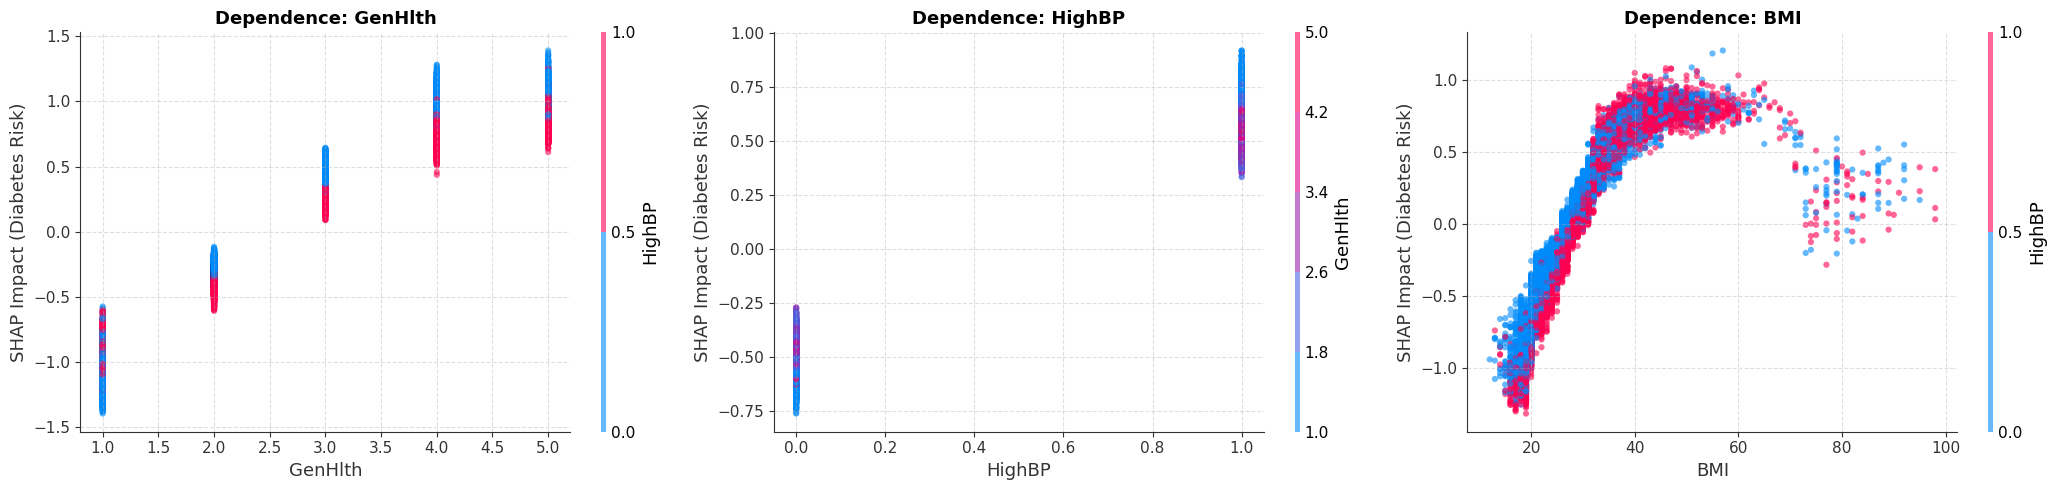

In [72]:
# ==============================================================================
# 1. PREPARAÇÃO DO DATASET DE EXIBIÇÃO (VALORES REAIS)
# ==============================================================================

# Usamos o DataFrame transformado que contém os nomes das colunas (OHE + Numeric)
X_display = pd.DataFrame(X_test_transformed, columns=feature_names_raw).copy()

# Limpeza visual dos nomes das colunas
X_display.columns = [col.split('__')[-1] for col in X_display.columns]

# Sincronizamos com X_test para restaurar a escala real das variáveis numéricas
# No CDC Diabetes, a principal variável numérica é o 'BMI'
cols_para_restaurar = ['BMI'] 

for col in cols_para_restaurar:
    if col in X_display.columns:
        # Substituímos o valor escalonado pelo valor original do X_test
        X_display[col] = X_test[col].values
        print(f"Restored to real scale for: {col}")

# ==============================================================================
# 2. IDENTIFICAR AS TOP FEATURES DO MODELO
# ==============================================================================

# Calculamos a importância média absoluta baseada no SHAP (Classe 1 - Diabetes)
vals = np.abs(shap_values_target).mean(0)

feature_importance = pd.DataFrame(
    list(zip(X_display.columns, vals)), 
    columns=['col_name','importance']
)

feature_importance.sort_values(by='importance', ascending=False, inplace=True)
top_features_names = feature_importance['col_name'].head(3).tolist()

print(f"Top 3 Features for dependency analysis: {top_features_names}")

# ==============================================================================
# 3. PLOTAGEM DOS DEPENDENCE PLOTS
# ==============================================================================

n_features = len(top_features_names)
fig, axes = plt.subplots(nrows=1, ncols=n_features, figsize=(7*n_features, 5))

if n_features == 1: axes = [axes]

for i, feature_name in enumerate(top_features_names):
    # O dependence_plot mostra a relação entre o valor da feature e o impacto no modelo
    shap.dependence_plot(
        feature_name, 
        shap_values_target, # Matriz SHAP da Classe 1 calculada anteriormente
        X_display,          # DataFrame com nomes limpos e escala real
        interaction_index="auto", # SHAP define automaticamente a cor baseada em outra feature
        ax=axes[i], 
        show=False,
        alpha=0.6,          
        dot_size=20         
    )
    
    axes[i].set_title(f"Dependence: {feature_name}", fontsize=13, fontweight='bold')
    axes[i].set_ylabel("SHAP Impact (Diabetes Risk)")
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

* Shap force plot

In [73]:
# ==============================================================================
# 1. PREPARAÇÃO DO DATAFRAME DE EXIBIÇÃO (VALORES REAIS)
# ==============================================================================
# A. Limpeza definitiva dos nomes (remove bin__, ohe__, num__, etc.)
X_display.columns = [col.split('__')[-1] for col in X_display.columns]

# B. Restauração da escala real (essencial para o BMI e Age)
# Sincronizamos com o X_test original para que o gráfico mostre "BMI: 32" e não "BMI: 1.2"
cols_reais = ['BMI'] # Adicione outras se não forem 0/1 (ex: Age, se não for OHE)
X_raw_full = X_test.copy()

for col in cols_reais:
    if col in X_display.columns:
        X_display[col] = X_raw_full[col].values

# ==============================================================================
# 2. AJUSTE DE VALORES SHAP E IDENTIFICAÇÃO DE CASOS EXTREMOS
# ==============================================================================

# A. Valor Base (Expected Value)
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)) and len(base_value) > 1:
    base_value = base_value[1]

# B. Cálculo das predições em log-odds para encontrar os extremos
# shap_values_target foi definido no bloco do Summary Plot (Classe 1)
total_predictions = shap_values_target.sum(axis=1) + base_value

idx_high = np.argmax(total_predictions) # Paciente com maior risco de diabetes
idx_low = np.argmin(total_predictions)  # Paciente com menor risco de diabetes

print(f"High-Risk Patient (Index {idx_high}): Log-odds {total_predictions[idx_high]:.2f}")
print(f"Low-Risk Pacient (Index {idx_low}): Log-odds {total_predictions[idx_low]:.2f}")

# ==============================================================================
# 3. GERAR FORCE PLOTS (INDIVIDUAL EXPLANATION)
# ==============================================================================

def plot_force_diabetes(idx_pos, title):
    print(f"\n{'='*50}\n{title}\n{'='*50}")
    
    # Inicializa JS (necessário para force_plot interativo no Jupyter)
    shap.initjs()
    
    # link='logit' converte a escala de log-odds para Probabilidade (0 a 100%)
    return shap.force_plot(
        base_value,
        shap_values_target[idx_pos],
        X_display.iloc[idx_pos, :],
        link="logit",
        matplotlib=False # Define como False para manter a interatividade
    )

# Exibir os perfis individuais
display(plot_force_diabetes(idx_high, "Clinical Profile: Maximum Risk of Diabetes"))
display(plot_force_diabetes(idx_low, "Clinical Profile: Minimal Risk of Diabetes"))

High-Risk Patient (Index 17278): Log-odds 2.52
Low-Risk Pacient (Index 7702): Log-odds -4.70

Clinical Profile: Maximum Risk of Diabetes



Clinical Profile: Minimal Risk of Diabetes


# Salvando o Modelo

In [99]:
# 1. Pipeline vencedor e classes
pipeline = grid_lgbm.best_estimator_
classes = le.classes_.tolist()

# 2. Conjunto de teste (já separado com train_test_split)
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred = pipeline.predict(X_test)

# 3. Calcular métricas no TESTE
ap     = average_precision_score(y_test, y_prob)
roc    = roc_auc_score(y_test, y_prob)
recall_pos = recall_score(y_test, y_pred, pos_label=1)
f1_pos     = f1_score(y_test, y_pred, pos_label=1)

# 4. Montar objeto consolidado
export_data = {
    "pipeline": pipeline,
    "classes": classes,
    "threshold": 0.25,
    "avg_precision": float(ap),
    "roc_auc": float(roc),
    "recall_pos": float(recall_pos),
    "f1_pos": float(f1_pos),
    "saved_at": datetime.utcnow().isoformat() + "Z",
    "version": "v1.0",
    "provenance": "Dados: Bank Marketing (campanhas telefônicas, instituição bancária portuguesa)."
}

# 5. Salvar com compressão
joblib.dump(export_data, "modelo_diabetes_vtl.pkl", compress=3)

print("Artefato salvo com métricas de TESTE:")
print(f"AP={ap:.4f}, ROC-AUC={roc:.4f}, Recall={recall_pos:.4f}, F1={f1_pos:.4f}")
# 2. Salvar com compressão máxima (3 a 9 são níveis comuns)
# Isso reduz o tamanho do arquivo, facilitando o upload/download
joblib.dump(export_data, "modelo_diabetes_vtl.pkl", compress=3)

Artefato salvo com métricas de TESTE:
AP=0.4421, ROC-AUC=0.8166, Recall=0.7881, F1=0.4516


['modelo_diabetes_vtl.pkl']

# Síntese